<a href="https://colab.research.google.com/github/hsmu-jeongeun/deep-learning-practice/blob/main/250507_deep_learning_model_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 14장 모델의 성능 향상시키기

### 1. 데이터의 확인과 검증셋

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd

!git clone https://github.com/taehojo/data.git
df = pd.read_csv('./data/wine.csv', header=None)
df

fatal: destination path 'data' already exists and is not an empty directory.


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [2]:
X = df.iloc[:,0:12]
y = df.iloc[:,12]

In [ ]:
# 학습 데이터셋과 테스트 데이터셋 구분
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델 구조 설정
model = Sequential()
model.add(Dense(30,  input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) # 이진 분류 문제이므로 손실함수로 binary_crossentropy를 사용

history=model.fit(X_train, y_train, epochs=50, batch_size=500, validation_split=0.25) # 0.8 x 0.25 = 0.2

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7585 - loss: 1.0323 - val_accuracy: 0.7685 - val_loss: 0.4556
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8424 - loss: 0.4078 - val_accuracy: 0.8992 - val_loss: 0.3309
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8868 - loss: 0.2999 - val_accuracy: 0.8869 - val_loss: 0.2954
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8999 - loss: 0.2772 - val_accuracy: 0.9169 - val_loss: 0.2356
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.2339 - val_accuracy: 0.9262 - val_loss: 0.2259
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9256 - loss: 0.2258 - val_accuracy: 0.9254 - val_loss: 0.2140
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.2205 - val_accuracy: 0.9300 - val_loss: 0.2102
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9274 - loss: 0.2153 - val_accuracy: 0.9277 - val_loss: 0.2052
Epoch 9

In [4]:
# 테스트 결과 출력
score=model.evaluate(X_test, y_test)
print('Test accuracy:', score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.9462 - loss: 0.1394
Test accuracy: 0.9461538195610046


## 2. 모델 업데이트하기

### 기본 코드 불러오기

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 모델 구조 설정
model = Sequential()
model.add(Dense(30,  input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

### 모델의 저장 설정 및 실행

In [ ]:
# 모델 저장 조건 설정
modelpath="./data/model/all/{epoch:02d}-{val_accuracy:.4f}.keras" # 모델이 저장될 위치와 파일명 설정, epoch:02d는 epoch 횟수를 2자리로 표현, val_accuracy:.4f는 검증 정확도를 소수점 4자리로 표현
checkpointer = ModelCheckpoint(filepath=modelpath, verbose=1) # 모델이 저장될 때마다 저장되는 모델의 파일명을 출력하도록 설정

history=model.fit(X_train, y_train, epochs=50, batch_size=500, validation_split=0.25, verbose=0, callbacks=[checkpointer]) # 모델 학습 시에 모델이 저장될 때마다 저장되는 모델의 파일명을 출력하도록 설정, verbose=0은 학습 과정에서 출력되는 로그를 최소화하도록 설정


Epoch 1: saving model to ./data/model/all/01-0.8154.keras

Epoch 1: finished saving model to ./data/model/all/01-0.8154.keras

Epoch 2: saving model to ./data/model/all/02-0.8885.keras

Epoch 2: finished saving model to ./data/model/all/02-0.8885.keras

Epoch 3: saving model to ./data/model/all/03-0.8923.keras

Epoch 3: finished saving model to ./data/model/all/03-0.8923.keras

Epoch 4: saving model to ./data/model/all/04-0.9169.keras

Epoch 4: finished saving model to ./data/model/all/04-0.9169.keras

Epoch 5: saving model to ./data/model/all/05-0.9238.keras

Epoch 5: finished saving model to ./data/model/all/05-0.9238.keras

Epoch 6: saving model to ./data/model/all/06-0.9231.keras

Epoch 6: finished saving model to ./data/model/all/06-0.9231.keras

Epoch 7: saving model to ./data/model/all/07-0.9262.keras

Epoch 7: finished saving model to ./data/model/all/07-0.9262.keras

Epoch 8: saving model to ./data/model/all/08-0.9285.keras

Epoch 8: finished saving model to ./data/model/all/

In [7]:
# 테스트 결과를 출력합니다.
score=model.evaluate(X_test, y_test)
print('Test accuracy:', score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9462 - loss: 0.1378 
Test accuracy: 0.9461538195610046


## 3. 그래프로 과적합 확인하기

In [8]:
# 그래프 확인을 위한 긴 학습
history=model.fit(X_train, y_train, epochs=2000, batch_size=500, verbose=0, validation_split=0.25)

In [9]:
hist_df=pd.DataFrame(history.history)
hist_df

,accuracy,loss,val_accuracy,val_loss
0,0.951245,0.133027,0.950769,0.128755
1,0.949961,0.130843,0.957692,0.128305
2,0.949961,0.130189,0.963846,0.133223
3,0.950475,0.130984,0.965385,0.131243
4,0.953041,0.127844,0.962308,0.121998
...,...,...,...,...
1995,0.995894,0.016531,0.993846,0.039406
1996,0.995894,0.016038,0.995385,0.040215
1997,0.995894,0.016678,0.993077,0.041902
1998,0.995894,0.017018,0.995385,0.038415


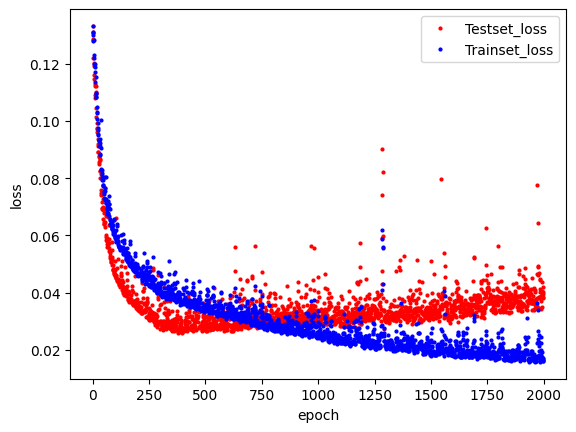

In [10]:
# 테스트 데이터셋 오차 저장
y_vloss=hist_df['val_loss']

# 학습셋 데이터셋 오차 저장
y_loss=hist_df['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, "o", c="red", markersize=2, label='Testset_loss')
plt.plot(x_len, y_loss, "o", c="blue", markersize=2, label='Trainset_loss')

plt.legend(loc='upper right')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 4. 학습의 자동 중단

### 기본 코드 불러오기

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import pandas as pd

### 학습의 자동 중단 및 최적화 모델 저장

In [12]:
# 학습이 언제 자동 중단될지 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

# 최적화 모델 저장 경로
modelpath="./data/model/Ch14-4-bestmodel.keras"

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=0, save_best_only=True)
history=model.fit(X_train, y_train, epochs=2000, batch_size=500, validation_split=0.25, verbose=1, callbacks=[early_stopping_callback,checkpointer])


Epoch 1/2000


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9956 - loss: 0.0160 - val_accuracy: 0.9931 - val_loss: 0.0391
Epoch 2/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9964 - loss: 0.0163 - val_accuracy: 0.9946 - val_loss: 0.0410
Epoch 3/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.9954 - val_loss: 0.0448
Epoch 4/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.0238 - val_accuracy: 0.9946 - val_loss: 0.0373
Epoch 5/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9897 - loss: 0.0380 - val_accuracy: 0.9931 - val_loss: 0.0375
Epoch 6/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9900 - loss: 0.0351 - val_accuracy: 0.9915 - val_loss: 0.0427
Epoch 7/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9936 - loss: 0.0243 - val_accuracy: 0.9946 - val_loss: 0.0344
Epoch 8/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9915 - loss: 0.0253 - val_accuracy: 0.9923 - val_loss: 0.0346
Epoc

In [13]:
# 테스트 결과 출력
score=model.evaluate(X_test, y_test)
print('Test accuracy:', score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.9877 - loss: 0.0915
Test accuracy: 0.9876922965049744
